In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression


%matplotlib inline

In [11]:
df = pd.read_excel("C:\\Users\\HP\\Downloads\\salary_dataset_3000.xlsx")
df.head()

,Experience,Age,Education_Level,Salary
0,6,39,1,3091
1,19,41,3,8085
2,14,44,1,6425
3,10,42,2,5713
4,7,41,2,4472


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Experience       3000 non-null   int64
 1   Age              3000 non-null   int64
 2   Education_Level  3000 non-null   int64
 3   Salary           3000 non-null   int64
dtypes: int64(4)
memory usage: 93.9 KB


In [13]:
df.describe()

,Experience,Age,Education_Level,Salary
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,9.915333,36.955333,2.001333,5107.573333
std,6.147419,7.481221,0.809249,2223.534539
min,0.000000,20.000000,1.000000,87.000000
25%,4.000000,31.000000,1.000000,3208.500000
50%,10.000000,37.000000,2.000000,5090.500000
75%,15.000000,42.000000,3.000000,6986.250000
max,20.000000,54.000000,3.000000,10417.000000


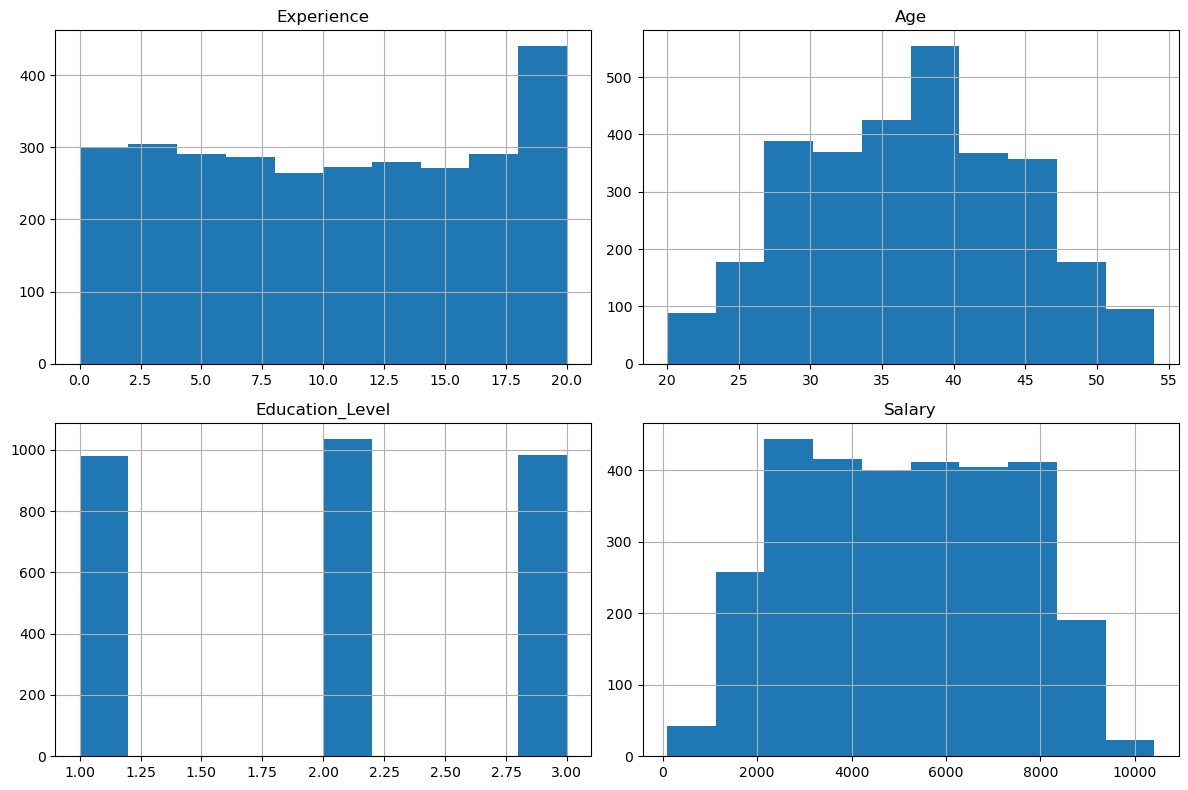

In [14]:
#DATA EXPLORATION
#distribution of key features 

df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

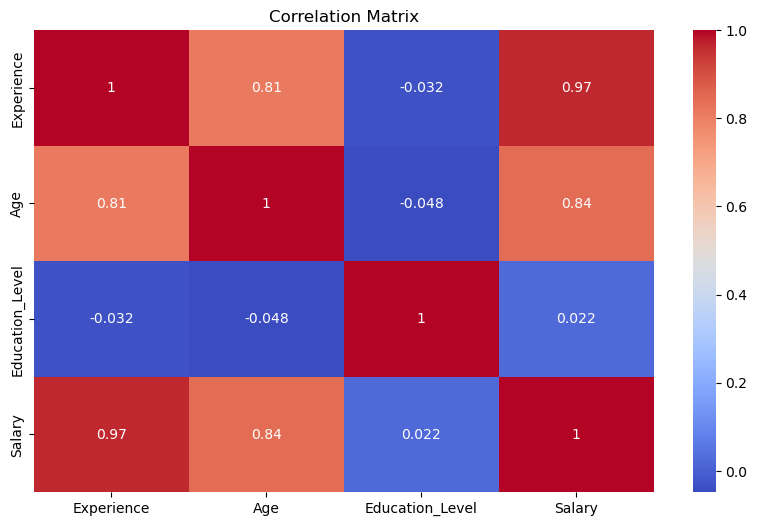

In [15]:
#correlation between features

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [16]:
#DATA PREPROSSING 
#handle missing values

df.isnull().sum()

Experience         0
Age                0
Education_Level    0
Salary             0
dtype: int64

In [17]:
df = df.dropna()

In [18]:
#remove duplicates 

df.duplicated().sum()

np.int64(2)

In [19]:
df = df.drop_duplicates()

In [20]:
# handle outlier using IQR
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [21]:
#MODDEL TRAINING 
X = df.drop("Salary", axis=1)
y = df["Salary"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
model = LinearRegression()
model.fit(X, y)


LinearRegression()

In [24]:
#MODEL EVALUATION 
#PREDICTION
y_pred = model.predict(X_test)

In [25]:
#EVALUATION METRICS 
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 406.66020786041025
Mean Squared Error (MSE): 253595.122300428
Root Mean Squared Error (RMSE): 503.58228950234934
R² Score: 0.9490817091393027


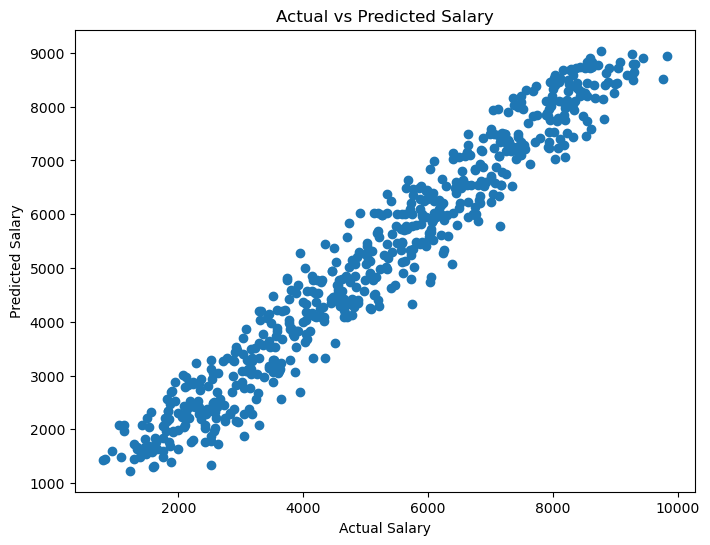

In [26]:
#VISUALIZATION OF MODEL PERFORMENCE 
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()

In [27]:
sample = pd.DataFrame(
    [[5, 28, 2]],
    columns=["Experience", "Age", "Education_Level"]
)

predicted_salary = model.predict(sample)
print("Predicted Salary:", int(predicted_salary[0]))

Predicted Salary: 3188


In [28]:
#CONCLUTION AND FEATURE WORK
print("""
The Multiple Linear Regression model was trained successfully.
The evaluation metrics show how well the model predicts salary.
A higher R² score indicates better model performance.
""")


The Multiple Linear Regression model was trained successfully.
The evaluation metrics show how well the model predicts salary.
A higher R² score indicates better model performance.



In [29]:
#FUTURE WORK
print("""
Future improvements may include:
- Feature scaling
- Feature engineering
- Trying advanced models (Random Forest, XGBoost)
- Cross-validation
""")


Future improvements may include:
- Feature scaling
- Feature engineering
- Trying advanced models (Random Forest, XGBoost)
- Cross-validation



In [31]:
import pickle

with open("model.pkl", "wb") as file:
    pickle.dump(model, file)
